# Car Price Prediction
Steps for completing this Project
1. Loading the Dataset
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Train-validation-test split
5. Neural Network Modelling
6. Final Model + Saving

# Importing and Loading the Dataset

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
file_path = 'C:/Users/Shashank/Desktop/My Folder/My-Projects/Car_Price/car_prediction_data.csv'
data = pd.read_csv(file_path)

In [37]:
print(data.to_markdown())

|     | Car_Name                  |   Year |   Selling_Price |   Present_Price |   Kms_Driven | Fuel_Type   | Seller_Type   | Transmission   |   Owner |
|----:|:--------------------------|-------:|----------------:|----------------:|-------------:|:------------|:--------------|:---------------|--------:|
|   0 | ritz                      |   2014 |            3.35 |           5.59  |        27000 | Petrol      | Dealer        | Manual         |       0 |
|   1 | sx4                       |   2013 |            4.75 |           9.54  |        43000 | Diesel      | Dealer        | Manual         |       0 |
|   2 | ciaz                      |   2017 |            7.25 |           9.85  |         6900 | Petrol      | Dealer        | Manual         |       0 |
|   3 | wagon r                   |   2011 |            2.85 |           4.15  |         5200 | Petrol      | Dealer        | Manual         |       0 |
|   4 | swift                     |   2014 |            4.6  |           6.87  |  

# Exploratory Data Analysis (EDA)

In [38]:
# Just checking the Statistics and Data Types
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [39]:
print(data.describe())

              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.644115   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [40]:
print(data.describe().to_markdown())

|       |       Year |   Selling_Price |   Present_Price |   Kms_Driven |       Owner |
|:------|-----------:|----------------:|----------------:|-------------:|------------:|
| count |  301       |       301       |       301       |        301   | 301         |
| mean  | 2013.63    |         4.6613  |         7.62847 |      36947.2 |   0.0431894 |
| std   |    2.89155 |         5.08281 |         8.64412 |      38886.9 |   0.247915  |
| min   | 2003       |         0.1     |         0.32    |        500   |   0         |
| 25%   | 2012       |         0.9     |         1.2     |      15000   |   0         |
| 50%   | 2014       |         3.6     |         6.4     |      32000   |   0         |
| 75%   | 2016       |         6       |         9.9     |      48767   |   0         |
| max   | 2018       |        35       |        92.6     |     500000   |   3         |


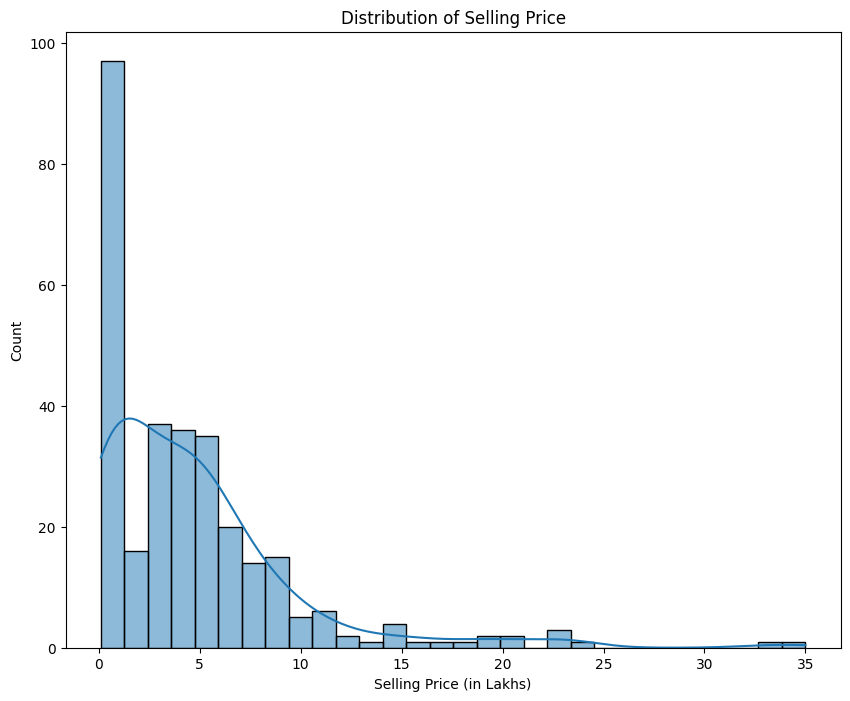

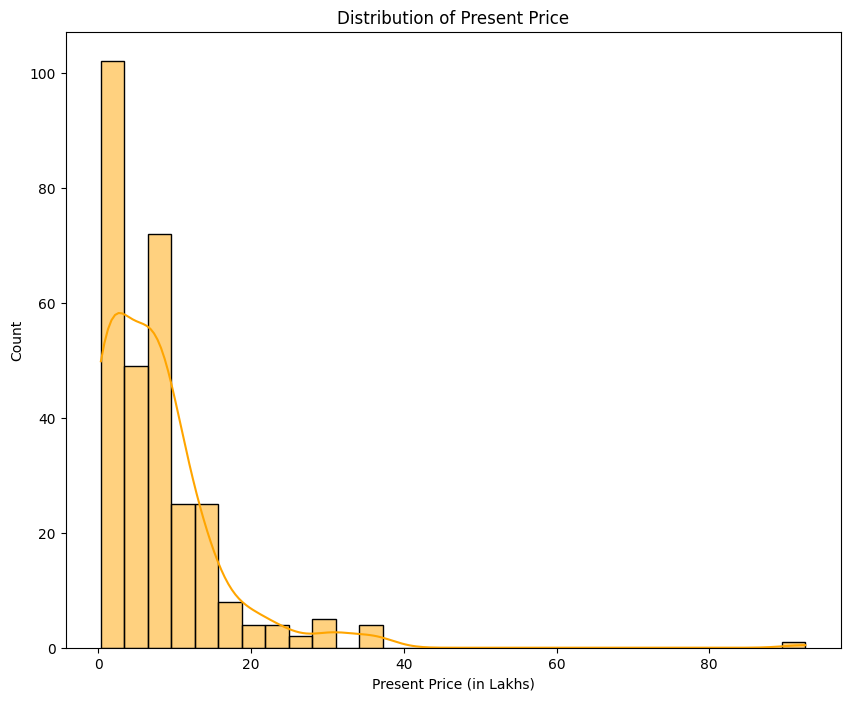

In [41]:
# Our Target Variable is Selling Price
# We will visualize the distribution of Selling Price
plt.figure(figsize = (10, 8))
sns.histplot(data['Selling_Price'], kde = True, bins = 30)
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price (in Lakhs)')
plt.show()

# We will also visualize the distribution of the Present Price
plt.figure(figsize = (10, 8))
sns.histplot(data['Present_Price'], kde = True, bins = 30, color = 'orange')
plt.title('Distribution of Present Price')
plt.xlabel('Present Price (in Lakhs)')
plt.show()

In [42]:
numerical_features = data.select_dtypes(include=['int64', 'float64'])
correlation_output = numerical_features.corr()['Selling_Price'].sort_values(ascending=False)
print(correlation_output)

Selling_Price    1.000000
Present_Price    0.878983
Year             0.236141
Kms_Driven       0.029187
Owner           -0.088344
Name: Selling_Price, dtype: float64


C:\Users\Shashank\AppData\Local\Temp\ipykernel_24700\3523578561.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = correlation_output.index, y = correlation_output.values, palette = 'coolwarm')


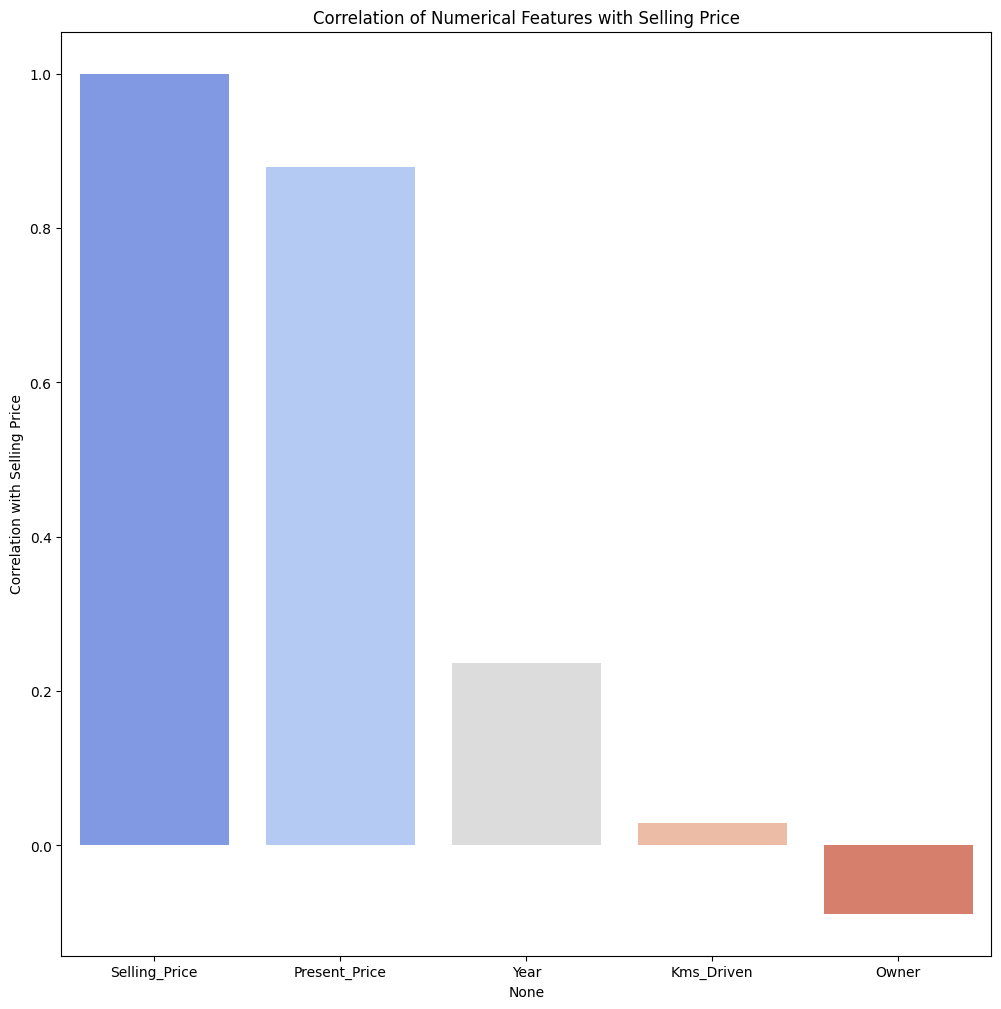

In [43]:
# finding the correlation between our selling price with our other numerical features
plt.figure(figsize = (12, 12))
sns.barplot(x = correlation_output.index, y = correlation_output.values, palette = 'coolwarm')
plt.title('Correlation of Numerical Features with Selling Price')
plt.ylabel('Correlation with Selling Price')
plt.show()

Here we can see how other numerical factors are affecting the Selling price.

In [44]:
# changing the year feature into car age
Present_Year = 2025
data['Age'] = Present_Year - data['Year']
print(data.to_markdown())

|     | Car_Name                  |   Year |   Selling_Price |   Present_Price |   Kms_Driven | Fuel_Type   | Seller_Type   | Transmission   |   Owner |   Age |
|----:|:--------------------------|-------:|----------------:|----------------:|-------------:|:------------|:--------------|:---------------|--------:|------:|
|   0 | ritz                      |   2014 |            3.35 |           5.59  |        27000 | Petrol      | Dealer        | Manual         |       0 |    11 |
|   1 | sx4                       |   2013 |            4.75 |           9.54  |        43000 | Diesel      | Dealer        | Manual         |       0 |    12 |
|   2 | ciaz                      |   2017 |            7.25 |           9.85  |         6900 | Petrol      | Dealer        | Manual         |       0 |     8 |
|   3 | wagon r                   |   2011 |            2.85 |           4.15  |         5200 | Petrol      | Dealer        | Manual         |       0 |    14 |
|   4 | swift                     

In [45]:
new_data = data.drop(['Year'], axis=1)
print(new_data.to_markdown())

|     | Car_Name                  |   Selling_Price |   Present_Price |   Kms_Driven | Fuel_Type   | Seller_Type   | Transmission   |   Owner |   Age |
|----:|:--------------------------|----------------:|----------------:|-------------:|:------------|:--------------|:---------------|--------:|------:|
|   0 | ritz                      |            3.35 |           5.59  |        27000 | Petrol      | Dealer        | Manual         |       0 |    11 |
|   1 | sx4                       |            4.75 |           9.54  |        43000 | Diesel      | Dealer        | Manual         |       0 |    12 |
|   2 | ciaz                      |            7.25 |           9.85  |         6900 | Petrol      | Dealer        | Manual         |       0 |     8 |
|   3 | wagon r                   |            2.85 |           4.15  |         5200 | Petrol      | Dealer        | Manual         |       0 |    14 |
|   4 | swift                     |            4.6  |           6.87  |        42450 | D

In [46]:
# again checking the correlation after adding Age feature
numerical_features = new_data.select_dtypes(include=['int64', 'float64'])
correlation_output = numerical_features.corr()['Selling_Price'].sort_values(ascending=False)
print(correlation_output)

Selling_Price    1.000000
Present_Price    0.878983
Kms_Driven       0.029187
Owner           -0.088344
Age             -0.236141
Name: Selling_Price, dtype: float64


C:\Users\Shashank\AppData\Local\Temp\ipykernel_24700\1935366085.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = correlation_output.index, y = correlation_output.values, palette='coolwarm')


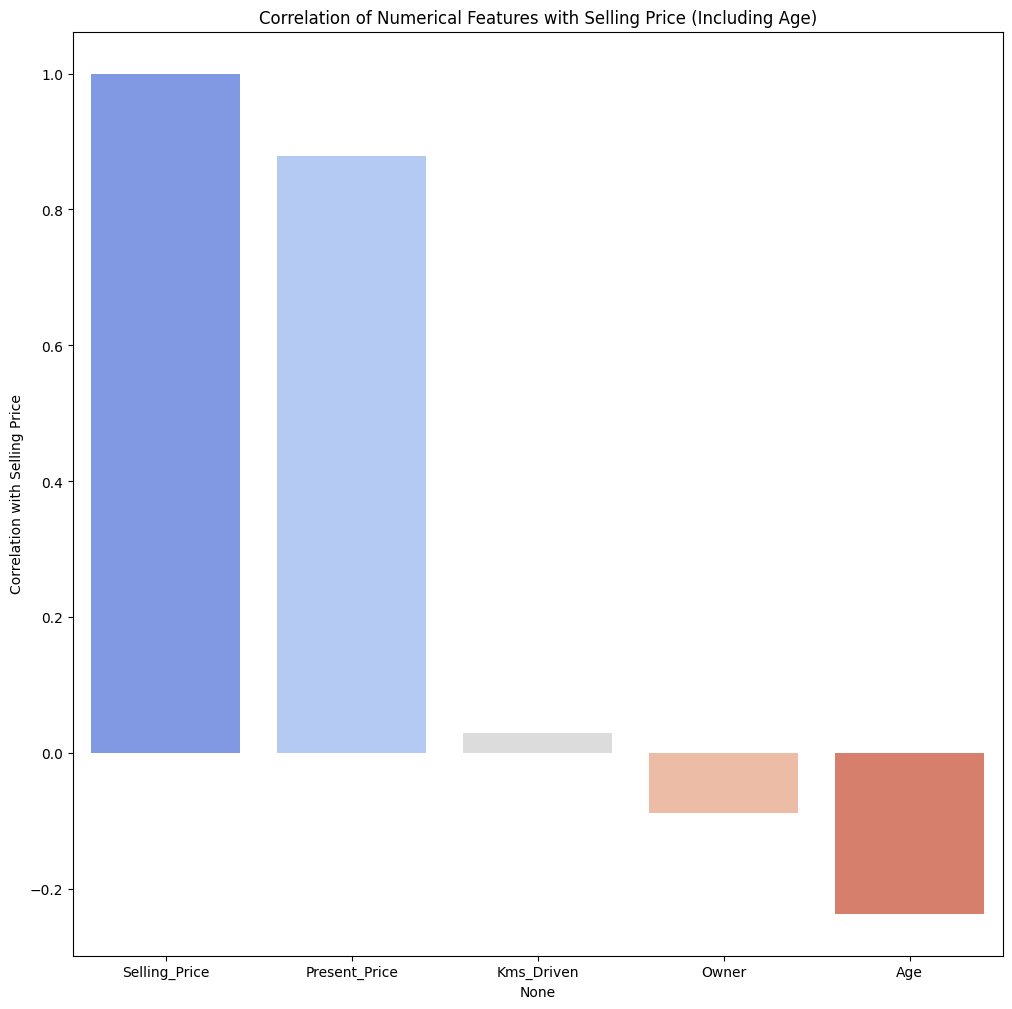

In [47]:
plt.figure(figsize = (12, 12))
sns.barplot(x = correlation_output.index, y = correlation_output.values, palette='coolwarm')
plt.title('Correlation of Numerical Features with Selling Price (Including Age)')
plt.ylabel('Correlation with Selling Price')
plt.show()

Let's Visualize the Relationship between the Categorical data with our output (Selling Price)

In [48]:
# we can use barplot as well as boxplot to visualize the categorical features against the selling price
# But I will use boxplot here
categorical_features = data[['Fuel_Type', 'Seller_Type', 'Transmission']] 
# Can also be written as data.select_dtypes(include=['object']) but this also includes 'Car_Name' which is not needed here
print(categorical_features.columns)
print(f"\n{categorical_features}")

Index(['Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object')

    Fuel_Type Seller_Type Transmission
0      Petrol      Dealer       Manual
1      Diesel      Dealer       Manual
2      Petrol      Dealer       Manual
3      Petrol      Dealer       Manual
4      Diesel      Dealer       Manual
..        ...         ...          ...
296    Diesel      Dealer       Manual
297    Petrol      Dealer       Manual
298    Petrol      Dealer       Manual
299    Diesel      Dealer       Manual
300    Petrol      Dealer       Manual

[301 rows x 3 columns]


C:\Users\Shashank\AppData\Local\Temp\ipykernel_24700\1621059555.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = data[feature], y = data['Selling_Price'], palette = 'Set3')


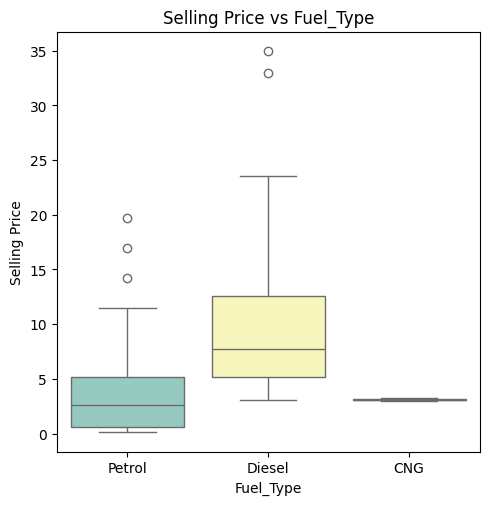

C:\Users\Shashank\AppData\Local\Temp\ipykernel_24700\1621059555.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = data[feature], y = data['Selling_Price'], palette = 'Set3')


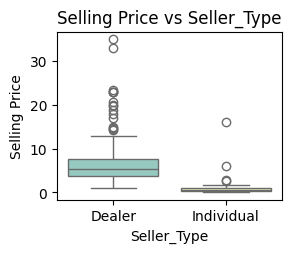

C:\Users\Shashank\AppData\Local\Temp\ipykernel_24700\1621059555.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = data[feature], y = data['Selling_Price'], palette = 'Set3')


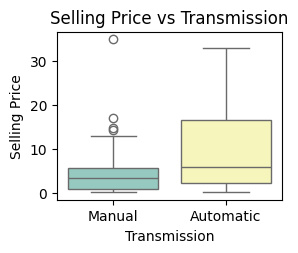

In [49]:
plt.figure(figsize = (12, 12))
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x = data[feature], y = data['Selling_Price'], palette = 'Set3')
    plt.title(f'Selling Price vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Selling Price')
    plt.show()

As through this Boxplot we can spot some outliers and data varience, their are many ways of removing the outliers. But right now, I am not focusing on outliers.

# Data Preprocessing
I will be focusing in transforming the categorical data into the format which is suitable for Neural Network to understand, and engineering better features if possible.

In [50]:
# dropping the 'Car_Name' column as it is not needed for our analysis
new_data = new_data.drop(['Car_Name'], axis=1)
print(new_data.to_markdown())

|     |   Selling_Price |   Present_Price |   Kms_Driven | Fuel_Type   | Seller_Type   | Transmission   |   Owner |   Age |
|----:|----------------:|----------------:|-------------:|:------------|:--------------|:---------------|--------:|------:|
|   0 |            3.35 |           5.59  |        27000 | Petrol      | Dealer        | Manual         |       0 |    11 |
|   1 |            4.75 |           9.54  |        43000 | Diesel      | Dealer        | Manual         |       0 |    12 |
|   2 |            7.25 |           9.85  |         6900 | Petrol      | Dealer        | Manual         |       0 |     8 |
|   3 |            2.85 |           4.15  |         5200 | Petrol      | Dealer        | Manual         |       0 |    14 |
|   4 |            4.6  |           6.87  |        42450 | Diesel      | Dealer        | Manual         |       0 |    11 |
|   5 |            9.25 |           9.83  |         2071 | Diesel      | Dealer        | Manual         |       0 |     7 |
|   6 | 

In [52]:
# Encoding the Categorical Features
new_data = pd.get_dummies(new_data, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)

In [55]:
print(new_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Selling_Price           301 non-null    float64
 1   Present_Price           301 non-null    float64
 2   Kms_Driven              301 non-null    int64  
 3   Owner                   301 non-null    int64  
 4   Age                     301 non-null    int64  
 5   Fuel_Type_Diesel        301 non-null    bool   
 6   Fuel_Type_Petrol        301 non-null    bool   
 7   Seller_Type_Individual  301 non-null    bool   
 8   Transmission_Manual     301 non-null    bool   
dtypes: bool(4), float64(2), int64(3)
memory usage: 13.1 KB
None


Scaling the numerical features like Selling_Price, Present_Price, Kms_Driven

# Train-Validation-Test Split

In [57]:
from sklearn.preprocessing import StandardScaler

In [70]:
# I will be seperating the features and target variable now
X = new_data.drop(['Selling_Price'], axis = 1)
Y = new_data['Selling_Price'].values.reshape(-1, 1) 
# using .values to convert it into numpy array for easy manipulation and usage, also reshaping it to make it a 2D array

In [69]:
print(f"Input features : \n{X.to_markdown()}\n Shape of input features : {X.shape}")

Input features : 
|     |   Present_Price |   Kms_Driven |   Owner |   Age | Fuel_Type_Diesel   | Fuel_Type_Petrol   | Seller_Type_Individual   | Transmission_Manual   |
|----:|----------------:|-------------:|--------:|------:|:-------------------|:-------------------|:-------------------------|:----------------------|
|   0 |           5.59  |        27000 |       0 |    11 | False              | True               | False                    | True                  |
|   1 |           9.54  |        43000 |       0 |    12 | True               | False              | False                    | True                  |
|   2 |           9.85  |         6900 |       0 |     8 | False              | True               | False                    | True                  |
|   3 |           4.15  |         5200 |       0 |    14 | False              | True               | False                    | True                  |
|   4 |           6.87  |        42450 |       0 |    11 | True       

In [71]:
print(f"\nTarget variable : \n{Y}\n Shape of target variable : {Y.shape}")


Target variable : 
[[ 3.35]
 [ 4.75]
 [ 7.25]
 [ 2.85]
 [ 4.6 ]
 [ 9.25]
 [ 6.75]
 [ 6.5 ]
 [ 8.75]
 [ 7.45]
 [ 2.85]
 [ 6.85]
 [ 7.5 ]
 [ 6.1 ]
 [ 2.25]
 [ 7.75]
 [ 7.25]
 [ 7.75]
 [ 3.25]
 [ 2.65]
 [ 2.85]
 [ 4.9 ]
 [ 4.4 ]
 [ 2.5 ]
 [ 2.9 ]
 [ 3.  ]
 [ 4.15]
 [ 6.  ]
 [ 1.95]
 [ 7.45]
 [ 3.1 ]
 [ 2.35]
 [ 4.95]
 [ 6.  ]
 [ 5.5 ]
 [ 2.95]
 [ 4.65]
 [ 0.35]
 [ 3.  ]
 [ 2.25]
 [ 5.85]
 [ 2.55]
 [ 1.95]
 [ 5.5 ]
 [ 1.25]
 [ 7.5 ]
 [ 2.65]
 [ 1.05]
 [ 5.8 ]
 [ 7.75]
 [14.9 ]
 [23.  ]
 [18.  ]
 [16.  ]
 [ 2.75]
 [ 3.6 ]
 [ 4.5 ]
 [ 4.75]
 [ 4.1 ]
 [19.99]
 [ 6.95]
 [ 4.5 ]
 [18.75]
 [23.5 ]
 [33.  ]
 [ 4.75]
 [19.75]
 [ 9.25]
 [ 4.35]
 [14.25]
 [ 3.95]
 [ 4.5 ]
 [ 7.45]
 [ 2.65]
 [ 4.9 ]
 [ 3.95]
 [ 5.5 ]
 [ 1.5 ]
 [ 5.25]
 [14.5 ]
 [14.73]
 [ 4.75]
 [23.  ]
 [12.5 ]
 [ 3.49]
 [ 2.5 ]
 [35.  ]
 [ 5.9 ]
 [ 3.45]
 [ 4.75]
 [ 3.8 ]
 [11.25]
 [ 3.51]
 [23.  ]
 [ 4.  ]
 [ 5.85]
 [20.75]
 [17.  ]
 [ 7.05]
 [ 9.65]
 [ 1.75]
 [ 1.7 ]
 [ 1.65]
 [ 1.45]
 [ 1.35]
 [ 1.35]
 [ 1.35]
 [ 1.25]
 [ 1.2 ]

In [85]:
# making a dedicated scaler object

# Scaling the Input Features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Scaling the Target Values
scaler_Y = StandardScaler()
Y_scaled = scaler_Y.fit_transform(Y)

In [86]:
print("\n Data after Standard Scaling \n")
print(f"Scaled Input Features : \n{X_scaled}\n")
print(type(X_scaled))


 Data after Standard Scaling 

Scaled Input Features : 
[[-0.23621461 -0.25622446 -0.17450057 ...  0.50932723 -0.73728539
   0.39148015]
 [ 0.22150462  0.1559105  -0.17450057 ... -1.96337432 -0.73728539
   0.39148015]
 [ 0.25742689 -0.77396901 -0.17450057 ...  0.50932723 -0.73728539
   0.39148015]
 ...
 [ 0.39068691  1.31334003 -0.17450057 ...  0.50932723 -0.73728539
   0.39148015]
 [ 0.56450434 -0.7198763  -0.17450057 ... -1.96337432 -0.73728539
   0.39148015]
 [-0.20029235 -0.81095812 -0.17450057 ...  0.50932723 -0.73728539
   0.39148015]]

<class 'numpy.ndarray'>


In [87]:
print(f"Scaled Target Variable : \n{Y_scaled}\n")
print(type(Y_scaled))

Scaled Target Variable : 
[[-2.58415906e-01]
 [ 1.74808835e-02]
 [ 5.10153723e-01]
 [-3.56950474e-01]
 [-1.20794869e-02]
 [ 9.04291994e-01]
 [ 4.11619155e-01]
 [ 3.62351871e-01]
 [ 8.05757426e-01]
 [ 5.49567550e-01]
 [-3.56950474e-01]
 [ 4.31326068e-01]
 [ 5.59421007e-01]
 [ 2.83524217e-01]
 [-4.75191956e-01]
 [ 6.08688290e-01]
 [ 5.10153723e-01]
 [ 6.08688290e-01]
 [-2.78122820e-01]
 [-3.96364301e-01]
 [-3.56950474e-01]
 [ 4.70412538e-02]
 [-5.14933140e-02]
 [-4.25924672e-01]
 [-3.47097018e-01]
 [-3.27390104e-01]
 [-1.00760598e-01]
 [ 2.63817303e-01]
 [-5.34312696e-01]
 [ 5.49567550e-01]
 [-3.07683190e-01]
 [-4.55485042e-01]
 [ 5.68947106e-02]
 [ 2.63817303e-01]
 [ 1.65282735e-01]
 [-3.37243561e-01]
 [-2.22603010e-03]
 [-8.49623313e-01]
 [-3.27390104e-01]
 [-4.75191956e-01]
 [ 2.34256933e-01]
 [-4.16071215e-01]
 [-5.34312696e-01]
 [ 1.65282735e-01]
 [-6.72261091e-01]
 [ 5.59421007e-01]
 [-3.96364301e-01]
 [-7.11674918e-01]
 [ 2.24403476e-01]
 [ 6.08688290e-01]
 [ 2.01773261e+00]
 [ 3.

We are done with Scaling the features and target values, now we will be split the data into Train:Validation:Test sets in 60:20:20.

In [88]:
from sklearn.model_selection import train_test_split

In [89]:
# Splitting the Data into Temparary and Test Sets in 80:20 ratio
X_temp, X_test, Y_temp, Y_test = train_test_split(X_scaled, Y_scaled, test_size = 0.2, random_state = 18)

In [90]:
# Splitting the Temparary Set into Training and Validation Sets in 75:25 ratio as 20% of 80% is 16% which makes the final test set 16% of the whole data
X_train, X_val, Y_train, Y_val = train_test_split(X_temp, Y_temp, test_size = 0.25, random_state = 18)

I will be converting the numpy arrays into tensors because of three main reasons :
1. PyTorch models only accept Tensors as input.
2. Tensors enable GPU processing; Numpy arrays do not.
3. Tensors are the backbone of Pytorch's learning mechanism.

In [91]:
import torch
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
# Converting the Training Data into Tensors
X_train_tensor = torch.from_numpy(X_train).float()
Y_train_tensor = torch.from_numpy(Y_train).float()

In [93]:
print(X_train_tensor)
print(Y_train_tensor)

tensor([[ 1.2725,  0.6453, -0.1745,  ...,  0.5093, -0.7373,  0.3915],
        [ 0.6920, -0.3077, -0.1745,  ...,  0.5093, -0.7373,  0.3915],
        [ 0.2053, -0.0244, -0.1745,  ...,  0.5093, -0.7373,  0.3915],
        ...,
        [-0.8202, -0.7791, -0.1745,  ...,  0.5093,  1.3563,  0.3915],
        [-0.0554,  0.5423, -0.1745,  ...,  0.5093, -0.7373,  0.3915],
        [ 0.2632,  0.0271, -0.1745,  ...,  0.5093, -0.7373,  0.3915]])
tensor([[-1.6973e-01],
        [ 7.3678e-01],
        [-3.1786e-02],
        [ 7.6634e-01],
        [-1.1061e-01],
        [ 1.7481e-02],
        [-2.5842e-01],
        [-4.2592e-01],
        [-8.0036e-01],
        [-7.7080e-01],
        [-8.6933e-01],
        [-8.4371e-01],
        [-3.2739e-01],
        [-2.2260e-03],
        [ 5.5942e-01],
        [-8.2400e-01],
        [-3.1786e-02],
        [-7.2153e-01],
        [ 2.6382e-01],
        [-3.9636e-01],
        [-3.1786e-02],
        [ 2.2345e+00],
        [ 2.3426e-01],
        [-3.1786e-02],
        [-8.79

In [94]:
# Converting the Validation Data into Tensors
X_val_tensor = torch.from_numpy(X_val).float()
Y_val_tensor = torch.from_numpy(Y_val).float()

# Printing the Validation Data Tensors
print(X_val_tensor)
print(Y_val_tensor)

tensor([[-6.7771e-01, -8.4867e-01, -1.7450e-01, -1.1681e+00, -4.9896e-01,
          5.0933e-01,  1.3563e+00,  3.9148e-01],
        [ 2.6631e+00,  1.3408e+00, -1.7450e-01,  5.6392e-01,  2.0042e+00,
         -1.9634e+00, -7.3729e-01, -2.5544e+00],
        [ 1.7615e+00,  1.1090e+00, -1.7450e-01,  1.2567e+00, -4.9896e-01,
          5.0933e-01, -7.3729e-01, -2.5544e+00],
        [-7.9707e-01, -2.8198e-01,  3.8659e+00,  1.9496e+00, -4.9896e-01,
          5.0933e-01,  1.3563e+00,  3.9148e-01],
        [-7.9011e-01,  1.3015e-01, -1.7450e-01, -1.2890e-01, -4.9896e-01,
          5.0933e-01,  1.3563e+00,  3.9148e-01],
        [-7.9278e-01, -5.6533e-01, -1.7450e-01, -1.2890e-01, -4.9896e-01,
          5.0933e-01,  1.3563e+00,  3.9148e-01],
        [ 2.0528e-01,  8.7715e-01, -1.7450e-01,  5.6392e-01,  2.0042e+00,
         -1.9634e+00, -7.3729e-01,  3.9148e-01],
        [-7.9278e-01,  3.3622e-01, -1.7450e-01,  1.9496e+00, -4.9896e-01,
          5.0933e-01,  1.3563e+00,  3.9148e-01],
        [-8.2835

In [95]:
# Converting the Test Data into Tensors
X_test_tensor = torch.from_numpy(X_test).float()
Y_test_tensor = torch.from_numpy(Y_test).float()

# Printing the Test Data Tensors
print(X_test_tensor)
print(Y_test_tensor)

tensor([[ 0.2053, -0.4511, -0.1745, -0.8217,  2.0042, -1.9634, -0.7373,  0.3915],
        [-0.7890, -0.4881, -0.1745, -0.4753, -0.4990,  0.5093,  1.3563,  0.3915],
        [ 0.3188,  0.2074, -0.1745, -0.4753,  2.0042, -1.9634, -0.7373,  0.3915],
        [ 0.9805,  0.5485, -0.1745, -0.1289,  2.0042, -1.9634, -0.7373,  0.3915],
        [-0.7982, -0.8229, -0.1745, -0.4753, -0.4990,  0.5093,  1.3563,  0.3915],
        [ 2.6631,  0.0786, -0.1745, -0.4753,  2.0042, -1.9634, -0.7373, -2.5544],
        [ 0.1497,  0.1396, -0.1745, -0.4753,  2.0042, -1.9634, -0.7373,  0.3915],
        [-0.8098, -0.5988, -0.1745, -0.1289, -0.4990,  0.5093,  1.3563,  0.3915],
        [-0.2235,  0.4135, -0.1745,  0.2175,  2.0042, -1.9634, -0.7373,  0.3915],
        [-0.3706, -0.6465, -0.1745, -0.8217, -0.4990,  0.5093, -0.7373,  0.3915],
        [-0.7832, -0.8744, -0.1745, -1.1681, -0.4990,  0.5093,  1.3563,  0.3915],
        [ 0.2748,  0.8401, -0.1745,  1.6032, -0.4990,  0.5093, -0.7373,  0.3915],
        [-0.7866

After Converting my numpy array into tensors, now I have to store them in Tensor Dataset which will hold and load it using DataLoader.

In [96]:
# Creating the Tensor Datasets
train_data = TensorDataset(X_train_tensor, Y_train_tensor)
val_data = TensorDataset(X_val_tensor, Y_val_tensor)
test_data = TensorDataset(X_test_tensor, Y_test_tensor)

In [97]:
# Creating DataLoaders for batching
batch_size = 32
train_loader = DataLoader(train_data, batch_size = batch_size, shuffle= True)
val_loader = DataLoader(val_data, batch_size = batch_size, shuffle = False)
test_loader = DataLoader(test_data, batch_size = batch_size, shuffle = False)

# Neural Network Modelling

In [102]:
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau # for defining the LR Scheduler and Monitoring

In [111]:
# Defining the Neural Network Model
class CarPriceModel(nn.Module):
    def __init__(self):
        super(CarPriceModel, self).__init__()
        self.layer1 = nn.Linear(8, 64)
        # As I have only 8 inputs but around 96 neurons in my first two layers due to this model is quite wide.
        # This increases the risk of overfitting on our small dataset.
        # solution : add 1 or 2 Dropout for Regularization.
        #self.dropout1 = nn.Dropout(0.2) # around 20% neurons
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 16)
        #self.dropout2 = nn.Dropout(0.2)

        self.layer4 = nn.Linear(16, 1) # Output layer

    def forward(self, x): # Applying the relu activation function 
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        #x = self.dropout1(x)
        x = torch.relu(self.layer3(x))
        x = self.layer4(x)
        #x = self.dropout2(x)

        return x

In [112]:
model = CarPriceModel()
print(model)

CarPriceModel(
  (layer1): Linear(in_features=8, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=32, bias=True)
  (layer3): Linear(in_features=32, out_features=16, bias=True)
  (layer4): Linear(in_features=16, out_features=1, bias=True)
)


In [113]:
# defining the loss function and optimizer

# for training I am using Mean Absolute Error (MAE) which is same as L1 Loss in PyTorch
loss_function = nn.L1Loss()

# I will be using Adam optimizer as it combines the advantages of Momentum and RMSprop.
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
# For Learning Rate I will be using the Learning Rate Scheduler
scheduler = ReduceLROnPlateau(optimizer,
                                     mode = 'min', # Monitor for minimizing the loss
                                     factor = 0.5, #Reduce LR by Half
                                     patience = 10, # wait 10 epochs before reducing
                                       )

# Evaluation and Prediction

Now comes very crucial step, as I will start training loop for this model.

In [114]:
# First I will set some parameters 

print_interval = 10 # Set to print stats every 10 epochs
num_epochs = 100
training_history = {'train_mae' : [], 'val_mae' : []}
best_val_mae = float('inf') # any positive infinite value

In [115]:
import torch.nn.functional as F

In [117]:
for epoch in range(1, num_epochs + 1):
    # Training phase
    model.train()
    epoch_train_loss = 0.0

    for inputs, labels in train_loader:
        # Forward Pass
        optimizer.zero_grad()
        outputs = model(inputs)

        # Calculating the loss (L1 Loss / Training MAE)
        loss = loss_function(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step() # updating the weights

        # adding the total loss accumulated in this epoch
        epoch_train_loss += loss.item() * inputs.size(0)

    # Calculate average Training MAE (L1 Loss) for the epoch
    avg_train_mae = epoch_train_loss / len(train_loader.dataset)
    training_history['train_mae'].append(avg_train_mae)

    # Validation Phase
    model.eval() # Set model to evaluation mode (disables Dropout)
    total_mae = 0.0

    with torch.no_grad(): # Disable gradient calculation
        for inputs, labels in val_loader:

            # Predict and calculate MAE
            output = model(inputs)
            mae_loss = F.l1_loss(output, labels)

            total_mae += mae_loss.item() * inputs.size(0)

        # Calculating the average Validation MAE (L1 Loss)
        avg_val_mae = total_mae / len(val_loader.dataset)
        training_history['val_mae'].append(avg_val_mae)

    # Printing the report
    if epoch % print_interval == 0:
        print(f"Epoch [{epoch}/{num_epochs}] | Train MAE : {avg_train_mae} | Val MAE : {avg_val_mae} | Current LR : {optimizer.param_groups[0]['lr']:.6f}")

Epoch [10/100] | Train MAE : 0.32853490511576333 | Val MAE : 0.2409215490023295 | Current LR : 0.001000
Epoch [20/100] | Train MAE : 0.12636727657583025 | Val MAE : 0.15954820861419042 | Current LR : 0.001000
Epoch [30/100] | Train MAE : 0.09913206249475479 | Val MAE : 0.14143195251623789 | Current LR : 0.001000
Epoch [40/100] | Train MAE : 0.09165332847171359 | Val MAE : 0.13100872536500294 | Current LR : 0.001000
Epoch [50/100] | Train MAE : 0.08218030830224356 | Val MAE : 0.12384342203537622 | Current LR : 0.001000
Epoch [60/100] | Train MAE : 0.07883031169573466 | Val MAE : 0.11140966316064199 | Current LR : 0.001000
Epoch [70/100] | Train MAE : 0.07398241211970648 | Val MAE : 0.10806839317083358 | Current LR : 0.001000
Epoch [80/100] | Train MAE : 0.07298702978425556 | Val MAE : 0.10857265641291937 | Current LR : 0.001000
Epoch [90/100] | Train MAE : 0.06700586155056953 | Val MAE : 0.10352229177951813 | Current LR : 0.001000
Epoch [100/100] | Train MAE : 0.06816920207606422 | Val 

Why Use F.l1_loss() in the Validation Loop?
The main reason for this common practice is one of convenience and efficiency in evaluation.

Convenience (Stateless vs. State)
nn.L1Loss() (The Module): This is a class (nn.Module). We instantiate it once (loss_function = nn.L1Loss()) and it retains some state (like a buffer for its parameters, even if L1Loss is simple). It is designed to be part of the learning process.

F.l1_loss() (The Functional): This is a simple, stateless function imported from torch.nn.functional (F). It performs the calculation on the spot and immediately returns the result. We don't need to define or initialize it beforehand.

In our validation loop, we are not using the loss to update weights (we are inside torch.no_grad()), we are only using it as a measurement tool. Using the functional form (F.l1_loss) is often considered cleaner for metrics calculation during evaluation.